In [1]:
import argparse
import logging
from json import dump
from pathlib import Path
from pprint import pprint

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.datasets.tsm_scan import CTScan
from src.utils.generic_utils import seed_everything

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-o', '--output_json_path', type=str, default='dataset_fingerprint.json', help='Output JSON path to save the results')
parser.add_argument('-fg', '--foreground_labels', type=int, nargs='+', default=[], help='Labels to be considered a foreground for computing the stats')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-o',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/dataset_fingerprint_fg_tumor.json',
]
args = parser.parse_args(args_input)


def collect_foreground_intensities(image: np.ndarray, segmentation: np.ndarray, num_samples: int) -> list[float]:
    assert not np.any(np.isnan(image)), "Images contains NaN values. grrrr.... :-("
    assert not np.any(np.isnan(segmentation)), "Segmentation contains NaN values. grrrr.... :-("

    foreground_pixels = image[segmentation > 0]
    num_fg = len(foreground_pixels)
    if num_fg == 0:
        logging.warning('Encountered scan with no foreground pixels')
        return []

    rs = np.random.RandomState(1234)
    intensities_per_channel = rs.choice(foreground_pixels, num_samples, replace=True) if num_fg > 0 else []
    return intensities_per_channel


def analyze_case(image_data: np.ndarray, segmentation_data: np.ndarray, slicing_dim: int, num_samples):
    # TODO: think about cropping intencities within zero-signal areas of the image_data for other datasets
    # data_cropped, seg_cropped, bbox = crop_to_nonzero(image_data, segmentation_data, slicing_dim)
    # spacing = properties_images['spacing']
    return collect_foreground_intensities(image_data, segmentation_data, num_samples)


def extract_fingerprint(datasets: list[torch.utils.data.Dataset], output_json_path: str, foreground_labels: list[int] = None) -> None:
    intencities_per_channel = []
    num_scans = sum(len(d.scans) for d in datasets)
    num_fg_samples_per_case = int(10e7 // num_scans)
    logging.info(f'Number of foreground pixels sampled per scan: {num_fg_samples_per_case} (num_scans={num_scans})')
    for dataset in datasets:
        assert hasattr(dataset, 'scans')
        scans = list(dataset.scans)
        s: CTScan
        for s in tqdm(scans):
            # clipping is done to filter out possible false positives produced by nnUNet in totalsegmentor dataset
            segm = s.segm.clip(0, len(s.classes) - 1)
            if foreground_labels:
                remove_labels = [i for i in range(len(s.classes) - 1) if i not in foreground_labels]
                for lb in remove_labels:
                    segm[segm == lb] = 0
            intencities = analyze_case(s.scan, segm, s.slicing_dim, num_fg_samples_per_case)
            intencities_per_channel.extend(intencities)

    fingerprint = {
        'mean': float(np.mean(intencities_per_channel)),
        'median': float(np.median(intencities_per_channel)),
        'std': float(np.std(intencities_per_channel)),
        'min': float(np.min(intencities_per_channel)),
        'max': float(np.max(intencities_per_channel)),
        'percentile_99_5': float(np.percentile(intencities_per_channel, 99.5)),
        'percentile_00_5': float(np.percentile(intencities_per_channel, 0.5)),
    }

    pprint(fingerprint)

    output_json_path = Path(output_json_path)
    if output_json_path.suffix:
        output_json_path.parent.mkdir(parents=True, exist_ok=True)
    else:
        output_json_path /= 'dataset_fingerprint.json'

    with open(output_json_path, 'w') as fid:
        dump(fingerprint, fid, indent=4)
    return output_json_path

In [2]:
with open(args.config_path) as fid:
    opt = yaml.safe_load(fid)
    opt = edict(opt)
seed_everything(opt.seed)

logging.info('Creating data loaders to be analyzed...')
transforms = get_transforms(opt.dataset)
params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
train_loader, test_loader = get_dataloaders(params, transforms)

logging.info(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')
logging.info('Extracting fingerprint...')
# json_path = extract_fingerprint([train_loader.dataset, test_loader.dataset], args.output_json_path, args.foreground_labels)
# logging.info(f'Saved the dataset fingerprint at: {json_path}')

INFO:root:Creating data loaders to be analyzed...
INFO:root:Total number of samples: 1328
INFO:root:Extracting fingerprint...


Instantiated training dataset for number of samples: 1277
Instantiated validation dataset for number of samples: 51


In [3]:
for batch in train_loader:
    print(batch.keys())
    print(batch['image'].shape)
    break

dict_keys(['image', 'masks', 'label', 'scan_name', 'slice_index'])
torch.Size([1, 1, 256, 256])


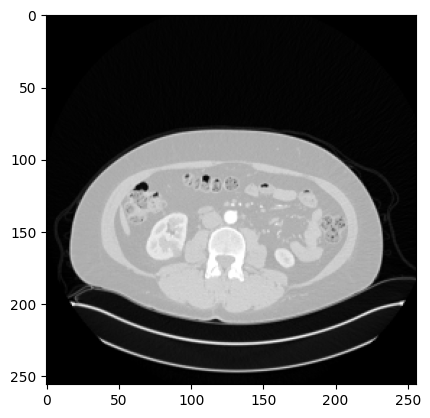

In [4]:
batch['image'].max()
import matplotlib.pyplot as plt

plt.imshow(batch['image'][0, 0], cmap='gray')

Creating data loaders to be visualized...
Instantiated training dataset for number of samples: 1277
Instantiated validation dataset for number of samples: 51
Total number of samples: 1328
Visualizing test set...
Visualizing 6 samples...


 17%|█▋        | 1/6 [02:08<10:40, 128.17s/it]

val_imaging_label_0_00000
val_imaging_label_0_00010


 83%|████████▎ | 5/6 [02:08<00:16, 16.25s/it] 

val_imaging_label_0_00020
val_imaging_label_1_00030
val_imaging_label_1_00040


100%|██████████| 6/6 [02:08<00:00, 21.47s/it]


val_imaging_label_0_00050
img shape: (256, 256, 3), range: (0, 254)


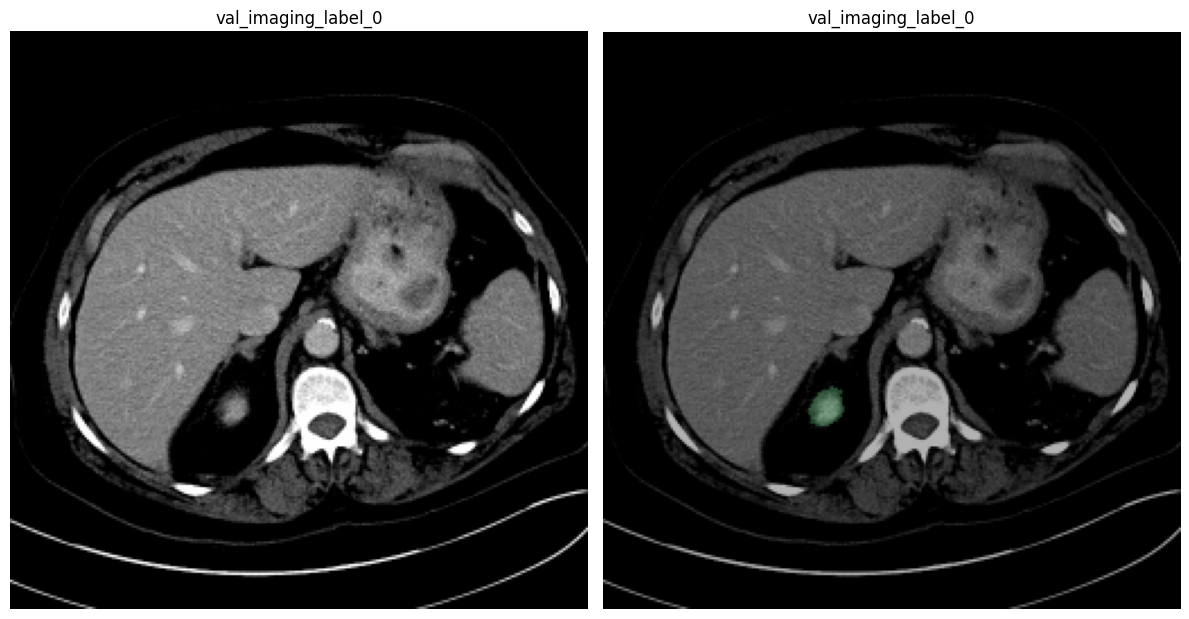

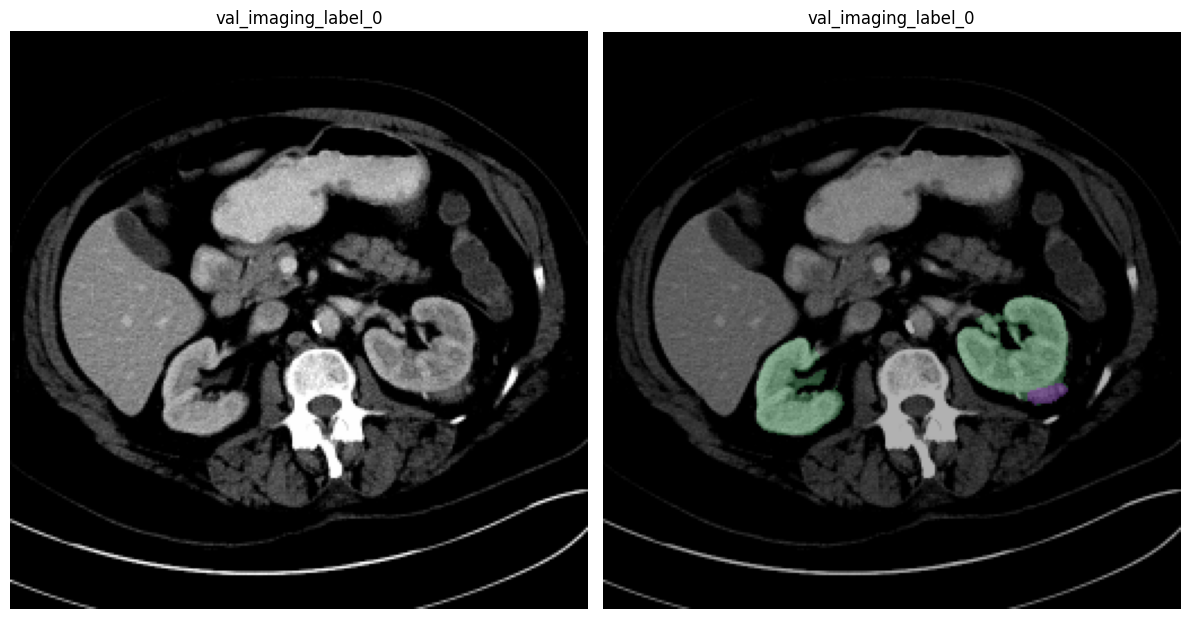

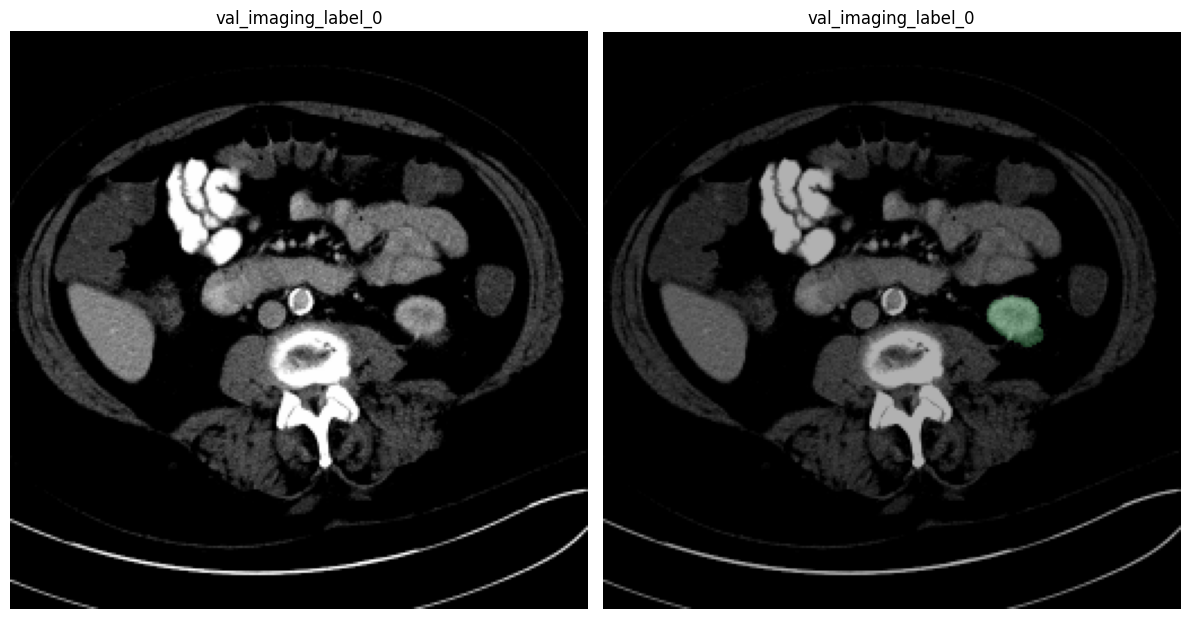

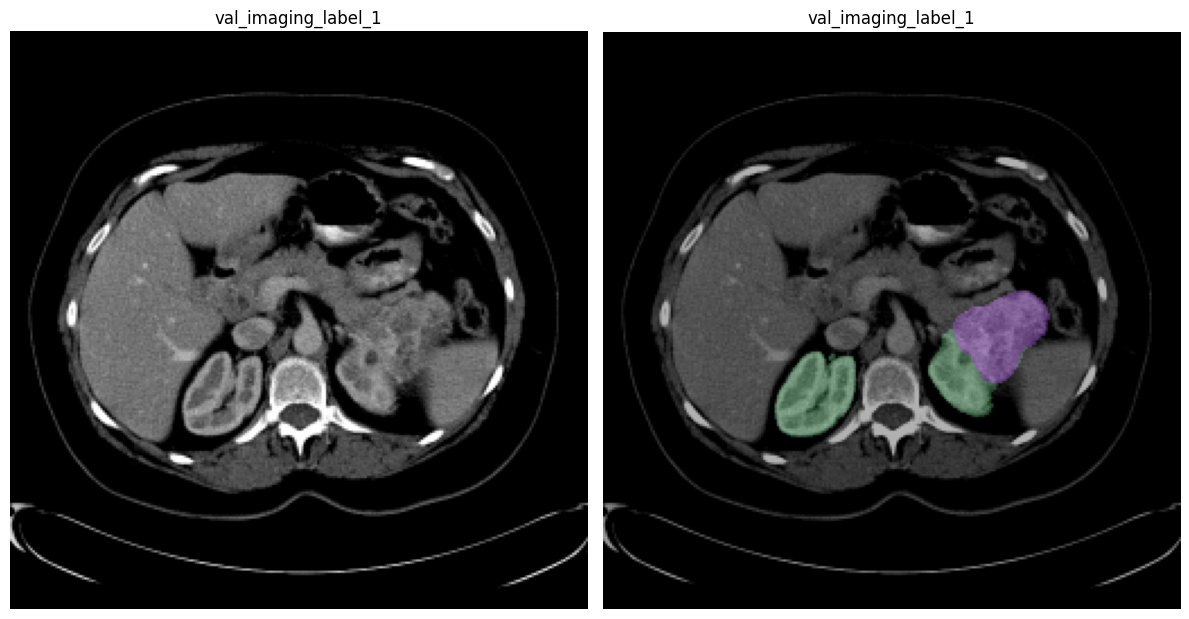

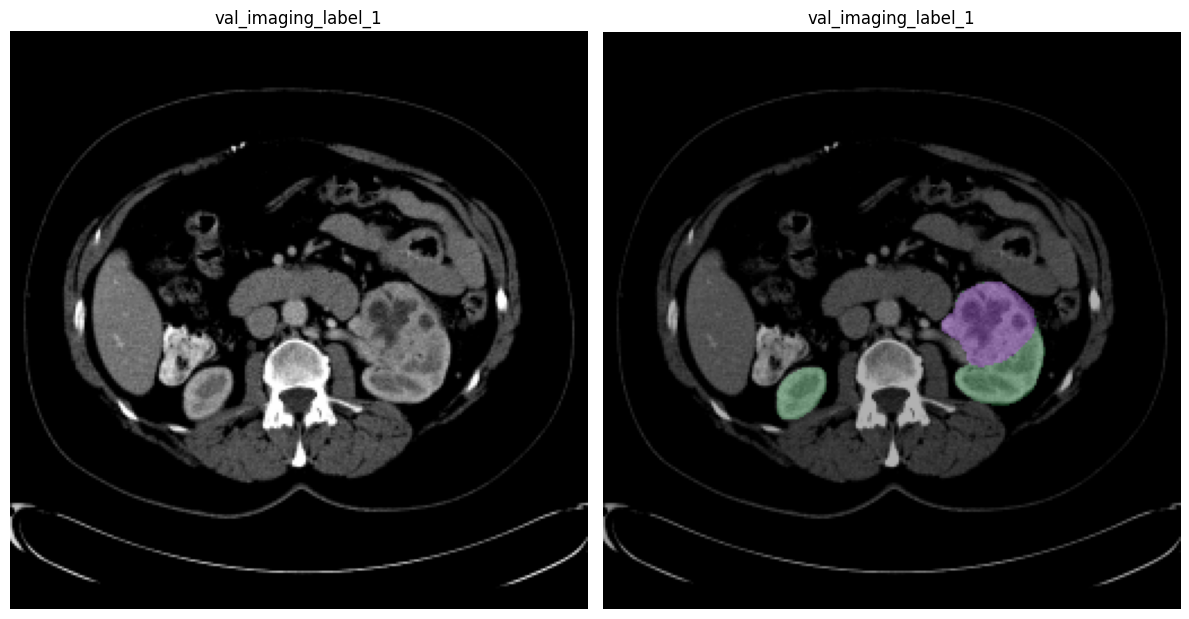

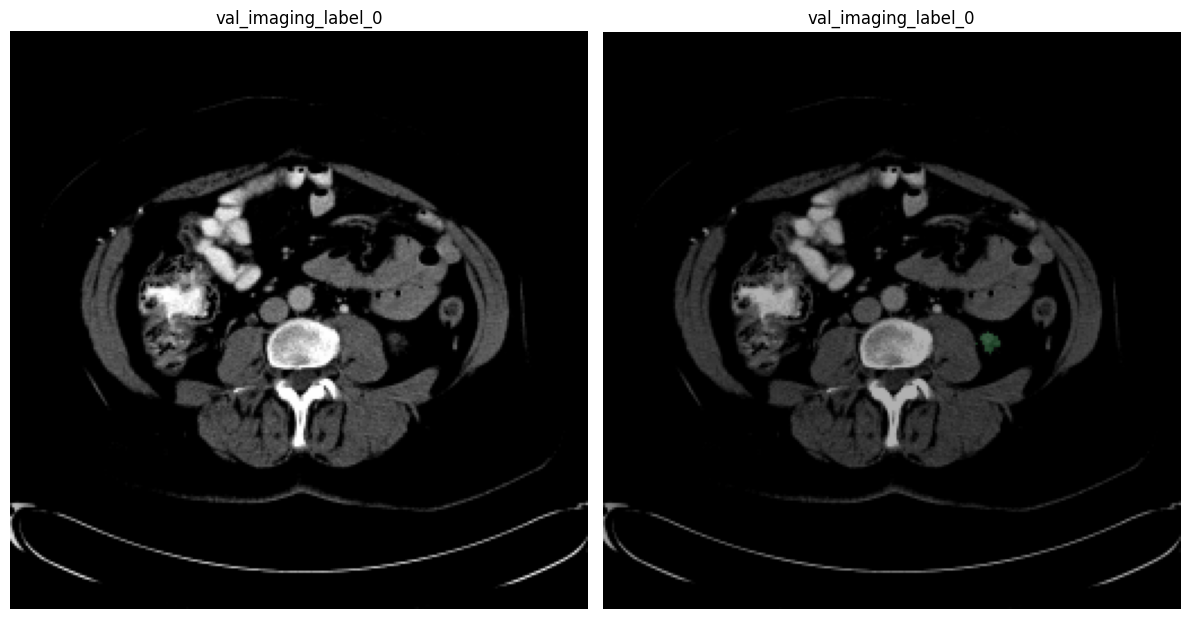

In [3]:
import argparse
import logging
import os
from pathlib import Path

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.utils.generic_utils import seed_everything
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-od', '--output_dir', type=str, required=True, help='Output directory where to write the visualizations')
parser.add_argument('-st', '--step_size', type=int, default=10, help='Every nth record to be visualized')
parser.add_argument('-s', '--sampling_only', action='store_true', default=False, help='Visualize only dataset examples where the sampler ')
parser.add_argument('-na', '--no_aug', action='store_true', default=False, help='Disable augmentations for visualization')
parser.add_argument('-la', '--label_agg_order', nargs='+', type=int, help='The order at which to overlay the classes masks.')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-od',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours',
]
args = parser.parse_args(args_input)
args.config_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/effv2s_kits_tumors.yaml'


def visualize_dataset(
    dataset: torch.utils.data.Dataset, out_dir: str, step: int = 10, alpha=0.7, sampling_only: bool = False, agg_order: list[int] = None
) -> None:
    if hasattr(dataset, 'scans'):
        for s in dataset.scans:
            s.load_masks = True
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    inds = list(range(0, len(dataset), step)) if not sampling_only else np.nonzero(dataset.get_sampling_labels())[0][::step]
    print(f'Visualizing {len(inds)} samples...')
    for i in tqdm(inds):
        s = dataset[i]
        assert s['masks'].shape[0] > 0, f'No masks are loaded in the dataset: {dataset}'
        assert s['image'].min() >= -1 and s['image'].max() <= 1, f'Image range is not in [0, 1]: {s["image"].min(), s["image"].max()}'
        name = dataset.split + '_' + s.get('scan_name', 'sample').split('.')[0] + '_label_' + str(s['label'].item())
        # print(f'input image range: {s["image"][0].min(), s["image"][0].max()}')
        img = ((s['image'][0].numpy() + 1) / 2) * 255
        img = np.stack([img.astype(np.uint8)] * 3, -1)
        # print(img.shape, s['scan_name'], s['slice_index'])

        vis_mask = np.zeros((*s['masks'].shape[1:], 3), dtype=np.uint8)

        for j in agg_order or range(1, s['masks'].shape[0]):
            # print(s['masks'].shape, dataset.classes)
            class_name = dataset.classes[j]
            # class_name = '1'
            color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
            # print(class_name, color)
            cl_mask = np.stack([s['masks'][j].numpy()] * 3, -1).astype(np.uint8) * np.array(color).reshape(1, 1, 3)
            vis_mask = vis_mask + cl_mask
        vis_mask = vis_mask.astype(np.uint8)

        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 7), sharex=True, sharey=True)
        # ax1.imshow(np.flip(img.transpose(1, 0, 2), (0, 1)))

        ax1.imshow(img)
        ax1.set_axis_off()
        ax1.set_title(name)

        vis_img = (img * alpha).astype(np.uint8) + ((1 - alpha) * vis_mask).astype(np.uint8)
        # ax2.imshow(np.flip(vis_img.transpose(1, 0, 2), (0, 1)))
        ax2.imshow(vis_img)
        ax2.set_axis_off()
        ax2.set_title(name)

        fig.tight_layout()

        name = f'{name}_{str(i).zfill(5)}'
        print(name)
        # plt.savefig(out_dir / f'{name}.jpg')

        # # fig.title
        # plt.close()
        # plt.cla()
        # plt.clf()
        # break
        if i >= 4:
            break
    print(f'img shape: {img.shape}, range: {img.min(), img.max()}')


def main(args):
    with open(args.config_path) as fid:
        opt = yaml.safe_load(fid)
        opt = edict(opt)
    seed_everything(opt.seed)

    print('Creating data loaders to be visualized...')
    transforms = get_transforms(opt.dataset)
    if args.no_aug:
        transforms['train'] = transforms['val']
    params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
    train_loader, test_loader = get_dataloaders(params, transforms)
    print(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')
    # print('Visualizing training set...')
    # visualize_dataset(train_loader.dataset, args.output_dir, step=args.step_size,
    #                   sampling_only=args.sampling_only, agg_order=args.label_agg_order)

    print('Visualizing test set...')
    visualize_dataset(test_loader.dataset, args.output_dir, step=args.step_size, sampling_only=args.sampling_only, agg_order=args.label_agg_order)


if __name__ == '__main__':
    main(args)

Creating data loaders to be visualized...
Using CT norm to change img from HU to [-1,1], no normalization applied in transforms(Aug)
Instantiated training dataset for number of samples: 25389
Instantiated validation dataset for number of samples: 6216
Total number of samples: 31605
Visualizing test set...
Visualizing 622 samples...


  0%|          | 2/622 [00:00<00:32, 18.94it/s]

val_imaging_label_0_00000
val_imaging_label_0_00010
val_imaging_label_0_00020
val_imaging_label_0_00030


  1%|          | 5/622 [00:00<00:29, 20.64it/s]

val_imaging_label_0_00040


  1%|          | 5/622 [00:00<00:36, 16.94it/s]


val_imaging_label_0_00050
img shape: (256, 256, 3), range: (0, 254)


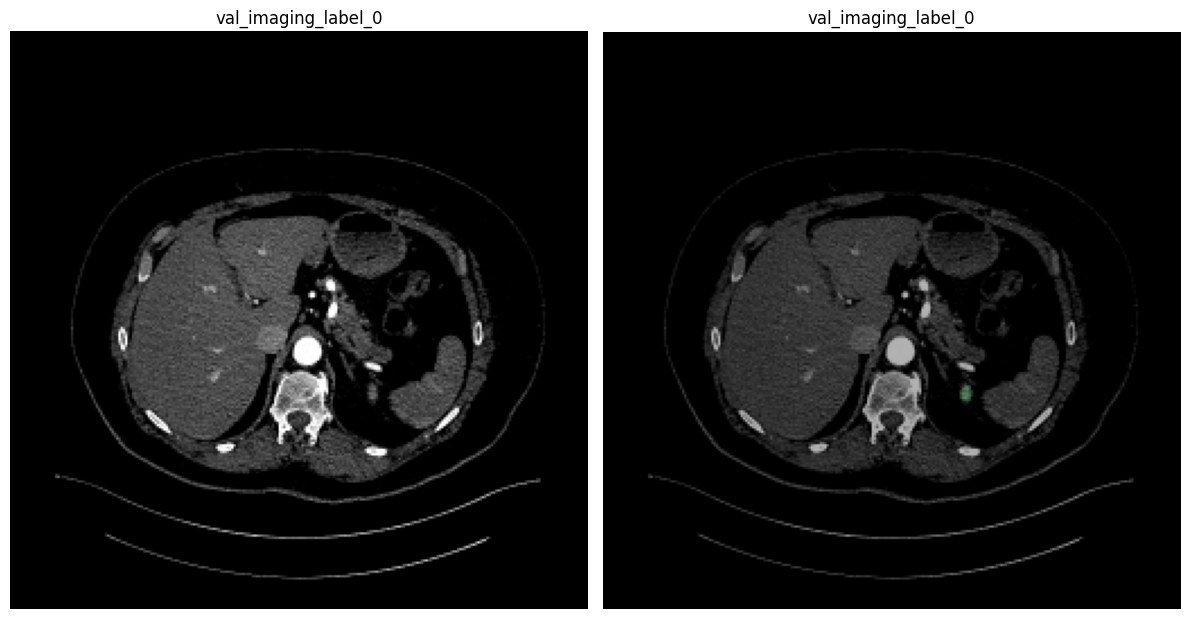

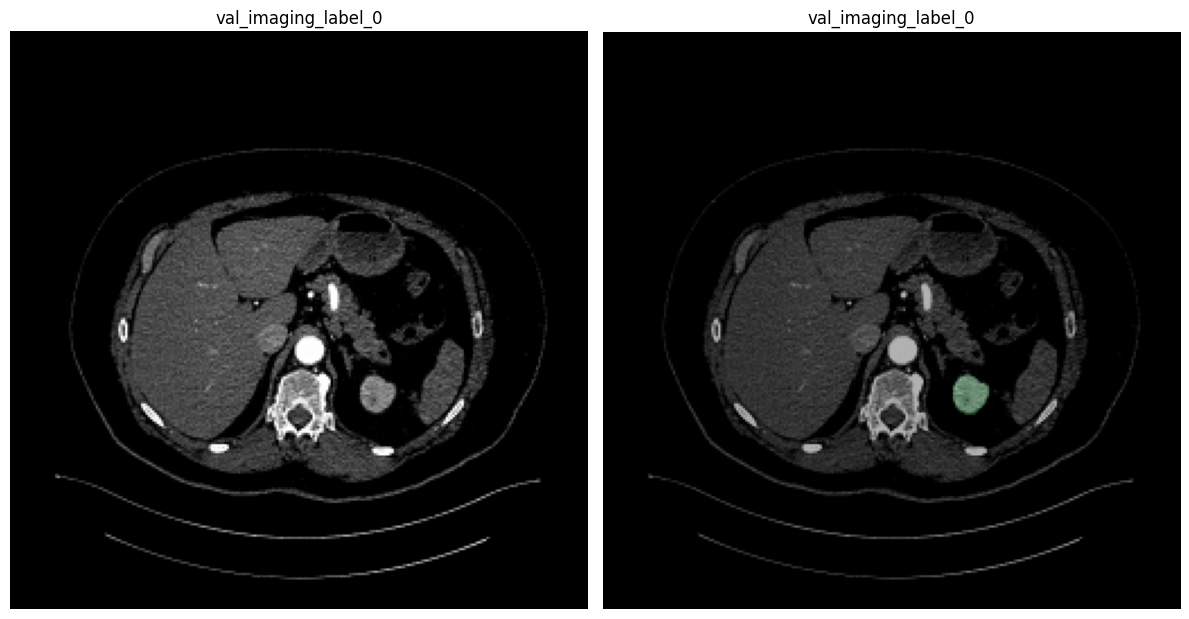

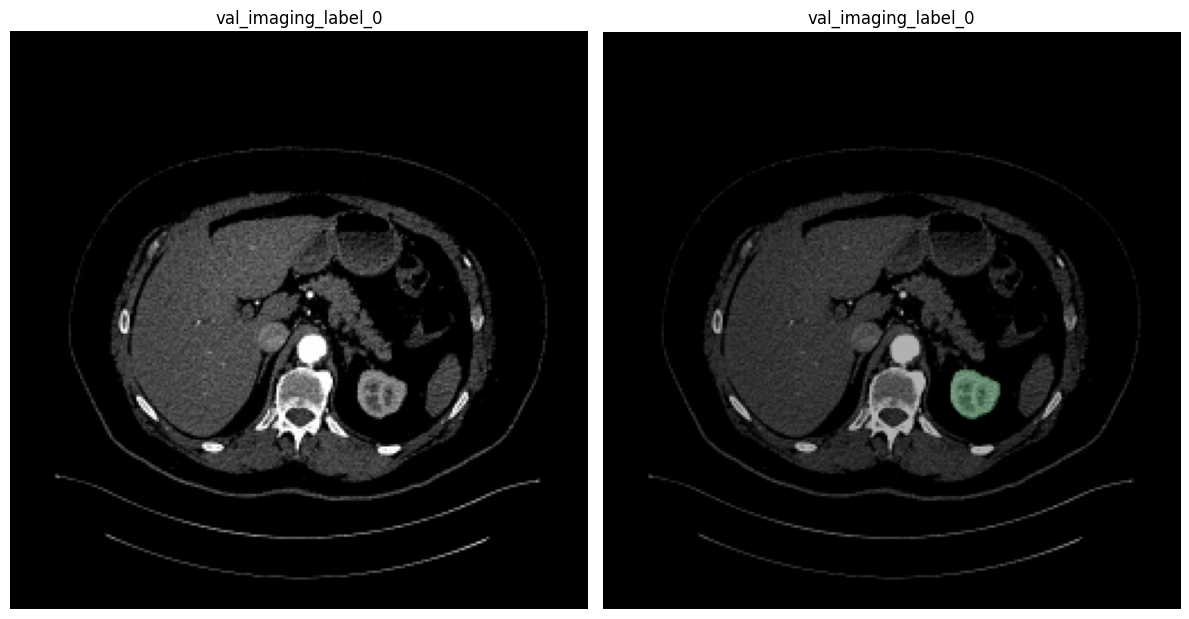

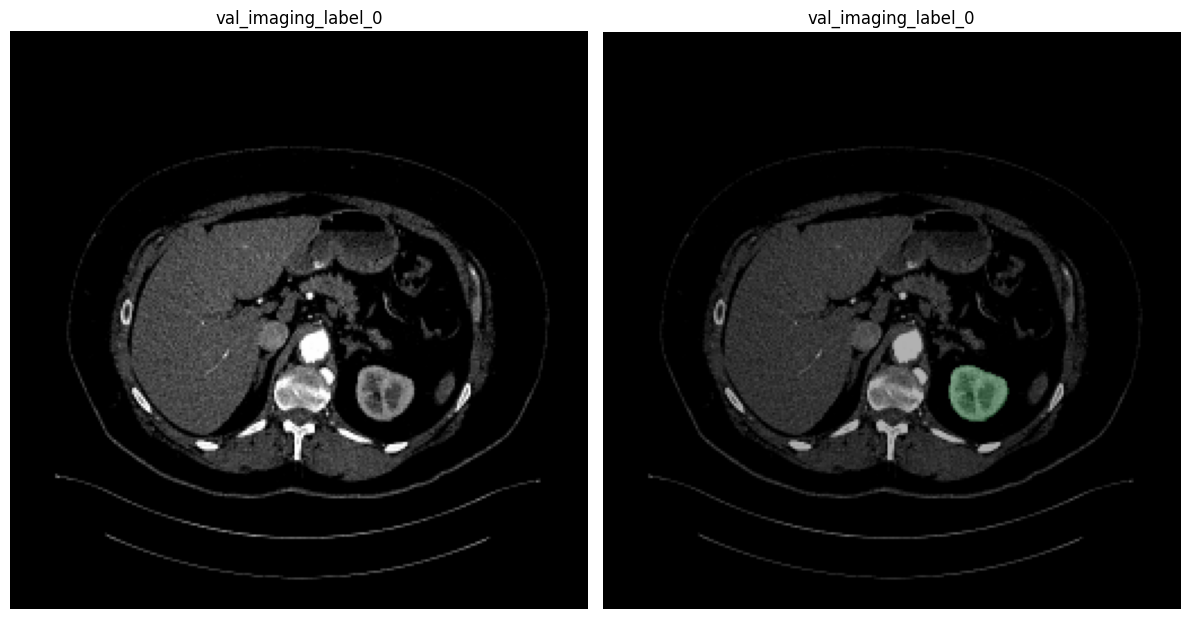

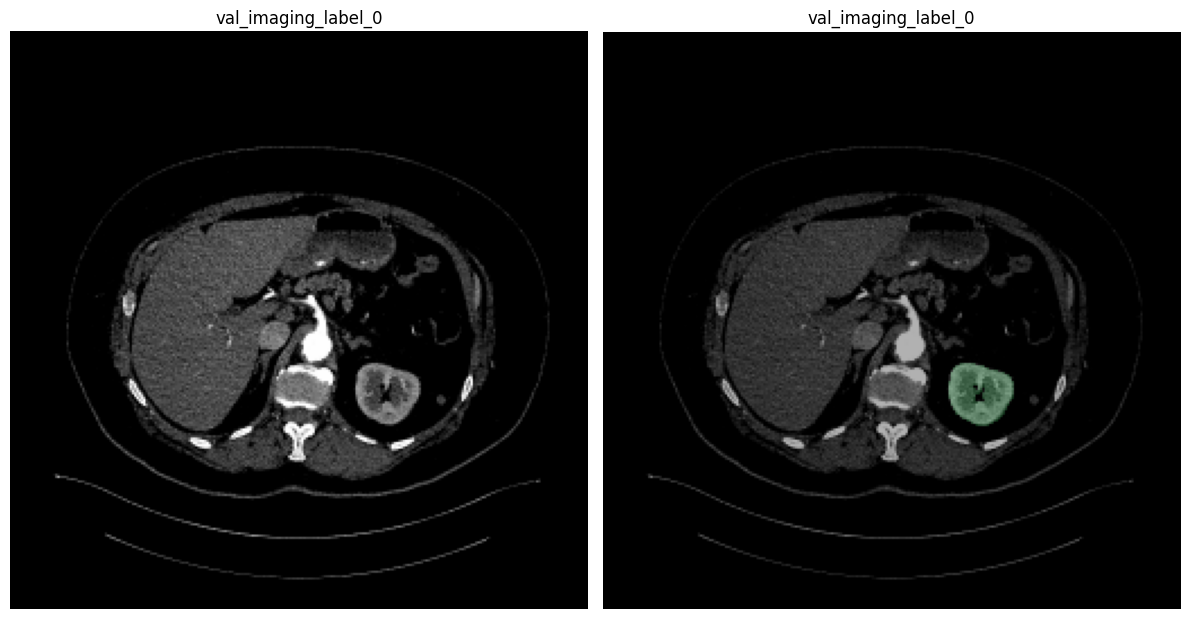

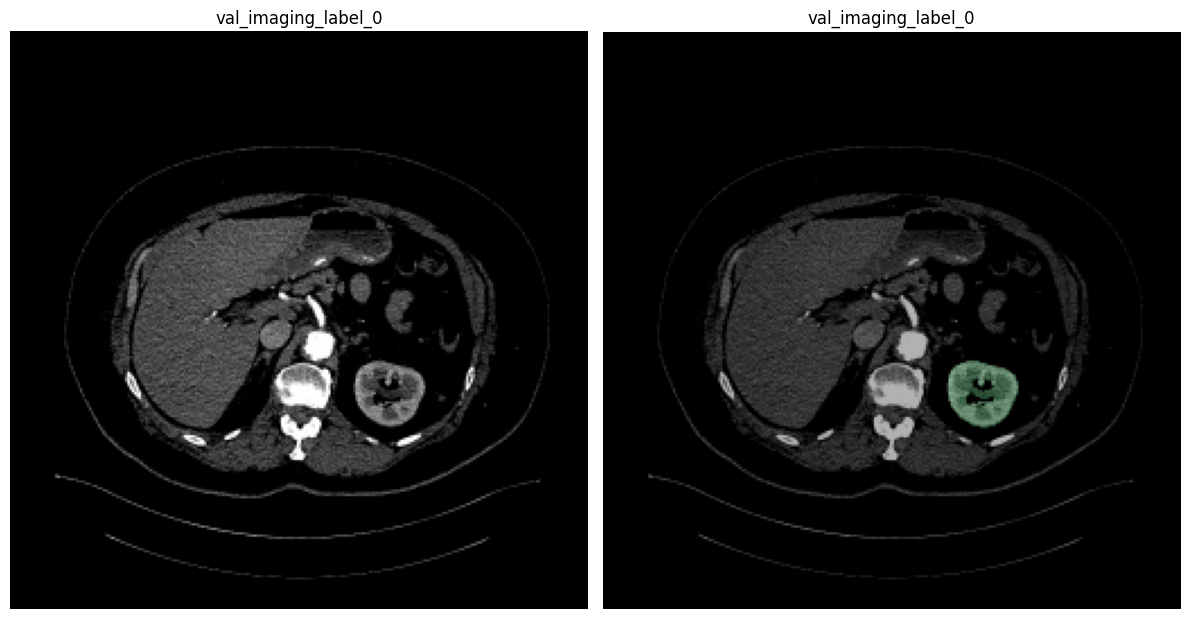

In [1]:
import argparse
import logging
import os
from pathlib import Path

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.utils.generic_utils import seed_everything
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-od', '--output_dir', type=str, required=True, help='Output directory where to write the visualizations')
parser.add_argument('-st', '--step_size', type=int, default=10, help='Every nth record to be visualized')
parser.add_argument('-s', '--sampling_only', action='store_true', default=False, help='Visualize only dataset examples where the sampler ')
parser.add_argument('-na', '--no_aug', action='store_true', default=False, help='Disable augmentations for visualization')
parser.add_argument('-la', '--label_agg_order', nargs='+', type=int, help='The order at which to overlay the classes masks.')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-od',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours',
]
args = parser.parse_args(args_input)
args.config_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/effv2s_kits_tumors.yaml'


def visualize_dataset(
    dataset: torch.utils.data.Dataset, out_dir: str, step: int = 10, alpha=0.7, sampling_only: bool = False, agg_order: list[int] = None
) -> None:
    if hasattr(dataset, 'scans'):
        for s in dataset.scans:
            s.load_masks = True
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    inds = list(range(0, len(dataset), step)) if not sampling_only else np.nonzero(dataset.get_sampling_labels())[0][::step]
    print(f'Visualizing {len(inds)} samples...')
    for i in tqdm(inds):
        s = dataset[i]
        assert s['masks'].shape[0] > 0, f'No masks are loaded in the dataset: {dataset}'
        assert s['image'].min() >= -1.01 and s['image'].max() <= 1, f'Image range is not in [-1, 1]: {s["image"].min(), s["image"].max()}'
        name = dataset.split + '_' + s.get('scan_name', 'sample').split('.')[0] + '_label_' + str(s['label'].item())
        # print(f'input image range: {s["image"][0].min(), s["image"][0].max()}')
        img = ((s['image'][0].numpy() + 1) / 2) * 255
        img = np.stack([img.astype(np.uint8)] * 3, -1)
        # print(img.shape, s['scan_name'], s['slice_index'])

        vis_mask = np.zeros((*s['masks'].shape[1:], 3), dtype=np.uint8)

        for j in agg_order or range(1, s['masks'].shape[0]):
            # print(s['masks'].shape, dataset.classes)
            class_name = dataset.classes[j]
            # class_name = '1'
            color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
            # print(class_name, color)
            cl_mask = np.stack([s['masks'][j].numpy()] * 3, -1).astype(np.uint8) * np.array(color).reshape(1, 1, 3)
            vis_mask = vis_mask + cl_mask
        vis_mask = vis_mask.astype(np.uint8)

        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 7), sharex=True, sharey=True)
        # ax1.imshow(np.flip(img.transpose(1, 0, 2), (0, 1)))

        ax1.imshow(img)
        ax1.set_axis_off()
        ax1.set_title(name)

        vis_img = (img * alpha).astype(np.uint8) + ((1 - alpha) * vis_mask).astype(np.uint8)
        # ax2.imshow(np.flip(vis_img.transpose(1, 0, 2), (0, 1)))
        ax2.imshow(vis_img)
        ax2.set_axis_off()
        ax2.set_title(name)

        fig.tight_layout()

        name = f'{name}_{str(i).zfill(5)}'
        print(name)
        # plt.savefig(out_dir / f'{name}.jpg')

        # # fig.title
        # plt.close()
        # plt.cla()
        # plt.clf()
        # break
        if i >= 50:
            break
    print(f'img shape: {img.shape}, range: {img.min(), img.max()}')


with open(args.config_path) as fid:
    opt = yaml.safe_load(fid)
    opt = edict(opt)
seed_everything(opt.seed)

print('Creating data loaders to be visualized...')
transforms = get_transforms(opt.dataset)
if args.no_aug:
    transforms['train'] = transforms['val']
params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
train_loader, test_loader = get_dataloaders(params, transforms)
print(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')
# print('Visualizing training set...')
# visualize_dataset(train_loader.dataset, args.output_dir, step=args.step_size,
#                   sampling_only=args.sampling_only, agg_order=args.label_agg_order)

print('Visualizing test set...')
visualize_dataset(test_loader.dataset, args.output_dir, step=args.step_size, sampling_only=args.sampling_only, agg_order=args.label_agg_order)

In [23]:
import argparse
import logging
import os
from pathlib import Path

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.utils.generic_utils import seed_everything
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR
from torch.utils.data import DataLoader, ConcatDataset, Dataset

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-od', '--output_dir', type=str, required=True, help='Output directory where to write the visualizations')
parser.add_argument('-st', '--step_size', type=int, default=10, help='Every nth record to be visualized')
parser.add_argument('-s', '--sampling_only', action='store_true', default=False, help='Visualize only dataset examples where the sampler ')
parser.add_argument('-na', '--no_aug', action='store_true', default=False, help='Disable augmentations for visualization')
parser.add_argument('-la', '--label_agg_order', nargs='+', type=int, help='The order at which to overlay the classes masks.')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-od',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours',
]
args = parser.parse_args(args_input)
args.config_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/effv2s_kits_tumors.yaml'
args.output_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/slice_dataset"
args.step_size = 1


with open(args.config_path) as fid:
    opt = yaml.safe_load(fid)
    opt = edict(opt)
seed_everything(opt.seed)

print('Creating data loaders to be visualized...')
transforms = get_transforms(opt.dataset)
if args.no_aug:
    transforms['train'] = transforms['val']
params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
train_loader, test_loader = get_dataloaders(params, transforms)
print(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')

print('saveing slice train and val set')


from PIL import Image


def saveslices_dataset(
    dataset: torch.utils.data.Dataset, out_dir: str, step: int = 10, alpha=0.7, sampling_only: bool = False, agg_order: list[int] = None
) -> None:
    num_kidney = 0
    num_tumor = 0
    num_cyst = 0

    if hasattr(dataset, 'scans'):
        for s in dataset.scans:
            s.load_masks = True
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    inds = list(range(0, len(dataset), step)) if not sampling_only else np.nonzero(dataset.get_sampling_labels())[0][::step]
    print(f'Visualizing {len(inds)} samples...')
    for i in tqdm(inds):
        s = dataset[i]
        assert s['masks'].shape[0] > 0, f'No masks are loaded in the dataset: {dataset}'
        assert s['image'].min() >= -1.01 and s['image'].max() <= 1, f'Image range is not in [-1, 1]: {s["image"].min(), s["image"].max()}'
        name = dataset.split + '_' + s.get('scan_name', 'sample').split('.')[0] + '_label_' + str(s['label'].item())
        # print(f'input image range: {s["image"][0].min(), s["image"][0].max()}')
        img = ((s['image'][0].numpy() + 1) / 2) * 255
        img = np.stack([img.astype(np.uint8)] * 3, -1)
        # print(img.shape, s['scan_name'], s['slice_index'])

        vis_mask = np.zeros((*s['masks'].shape[1:], 3), dtype=np.uint8)
        if s['masks'][1].sum() > 0:
            num_kidney += 1
        if s['masks'][2].sum() > 0:
            num_tumor += 1
        if s['masks'][3].sum() > 0:
            num_cyst += 1

        for j in agg_order or range(1, s['masks'].shape[0]):
            # print(s['masks'].shape, dataset.classes)
            class_name = dataset.classes[j]

            color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
            # print(class_name, color)
            cl_mask = np.stack([s['masks'][j].numpy()] * 3, -1).astype(np.uint8) * np.array(color).reshape(1, 1, 3)
            vis_mask = vis_mask + cl_mask
        vis_mask = vis_mask.astype(np.uint8)
        # print(f'image shape: {img.shape}, mask shape: {vis_mask.shape}')
        # print(f"image range: {img.min(), img.max()}, mask range: {s['masks'].min(), s['masks'].max()}")
        vis_img = (img * alpha).astype(np.uint8) + ((1 - alpha) * vis_mask).astype(np.uint8)  # blended image

        # fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 7), sharex=True, sharey=True)
        # ax1.imshow(img)
        # ax1.set_axis_off()
        # ax2.imshow(vis_img)
        # ax2.set_axis_off()
        # ax2.set_title(name)

        # img_name = f"{s['scan_casename']}_slice{s['slice_index']}"
        # name = f'{img_name}_label{str(s["label"].item())}'
        # print(name) # 0001_023.png(processed slice); 0001_023_mask.png
        # Image.fromarray(img).save(out_dir / 'images' / f'{name}.png')
        # Image.fromarray(vis_img).save(out_dir / 'masks' / f'{name}_mask.png')

        # break
    print(f'num_kidney: {num_kidney}, num_tumor: {num_tumor}, num_cyst: {num_cyst}')


saveslices_dataset(train_loader.dataset, args.output_dir, step=args.step_size, sampling_only=args.sampling_only, agg_order=args.label_agg_order)
# print('train set saved')
# saveslices_dataset(test_loader.dataset, args.output_dir, step=args.step_size,
#                     sampling_only=args.sampling_only, agg_order=args.label_agg_order)

Creating data loaders to be visualized...
Using CT norm to change img from HU to [-1,1], no normalization applied in transforms(Aug)


Instantiated training dataset for number of samples: 25389
[KiTS dataset] Number of slices with positive sampling label: 1195
[Merged dataset] Number of slices with positive sampling label: 1195
[Merged dataset] Number of slices with negtive sampling label: 5021
Instantiated validation dataset for number of samples: 6216
Total number of samples: 31605
saveing slice train and val set
Visualizing 25389 samples...


  9%|▊         | 2196/25389 [00:13<02:21, 163.79it/s]


KeyboardInterrupt: 

In [26]:
# kits_visdataset
import argparse
import logging
import os
from pathlib import Path

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.utils.generic_utils import seed_everything
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR
from torch.utils.data import DataLoader, ConcatDataset, Dataset

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-od', '--output_dir', type=str, required=True, help='Output directory where to write the visualizations')
parser.add_argument('-st', '--step_size', type=int, default=10, help='Every nth record to be visualized')
parser.add_argument('-s', '--sampling_only', action='store_true', default=False, help='Visualize only dataset examples where the sampler ')
parser.add_argument('-na', '--no_aug', action='store_true', default=False, help='Disable augmentations for visualization')
parser.add_argument('-la', '--label_agg_order', nargs='+', type=int, help='The order at which to overlay the classes masks.')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-od',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours',
]
args = parser.parse_args(args_input)
args.config_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/kits_visdataset.yaml'
args.output_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/slice_dataset"
args.step_size = 1


with open(args.config_path) as fid:
    opt = yaml.safe_load(fid)
    opt = edict(opt)
seed_everything(opt.seed)

print('Creating data loaders to be visualized...')
transforms = get_transforms(opt.dataset)
if args.no_aug:
    transforms['train'] = transforms['val']
params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
train_loader, test_loader = get_dataloaders(params, transforms)
print(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')

print('saveing slice train and val set')

saveslices_dataset(test_loader.dataset, args.output_dir, step=args.step_size, sampling_only=args.sampling_only, agg_order=args.label_agg_order)

Creating data loaders to be visualized...
Using CT norm to change img from HU to [-1,1], no normalization applied in transforms(Aug)
Instantiated training dataset for number of samples: 26011
[KiTS dataset] Number of slices with positive sampling label: 2138
[Merged dataset] Number of slices with positive sampling label: 2138
[Merged dataset] Number of slices with negtive sampling label: 4226
Instantiated validation dataset for number of samples: 6364
Total number of samples: 32375
saveing slice train and val set
Visualizing 6364 samples...


100%|██████████| 6364/6364 [00:38<00:00, 165.40it/s]

num_kidney: 6355, num_tumor: 2136, num_cyst: 1155
